In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path
import json

plt.style.use('default')

In [70]:
cnt_points = 11
fpr_range = [0, 0.4]
tpr_range = [0.6, 1]

In [71]:
q = 1.0/5
s = 30

In [72]:
FPR = np.linspace(*fpr_range, num = cnt_points)[:, None] # column vec
TPR = np.linspace(*tpr_range, num = cnt_points)[:, None] # column vec

In [73]:
p_acc = q * (1 - TPR) + (1-q) * (1 - FPR.T) # (TPR, FPR)
p_FO = q * (1 - TPR) / p_acc # (TPR, FPR)

expected_count = (s / p_acc) 

note that: rows-cols = y-x

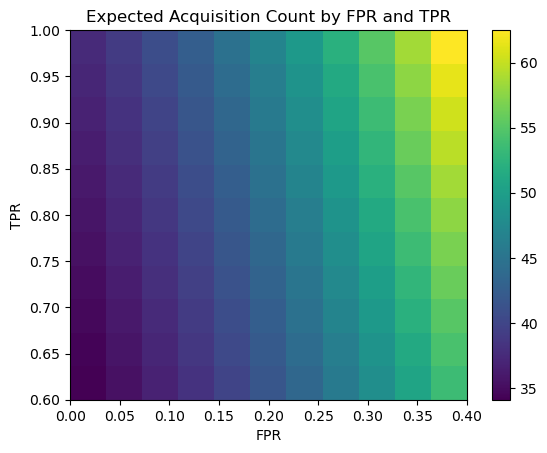

In [74]:
plt.imshow(expected_count, origin='lower', extent=fpr_range + tpr_range,
           aspect='auto') 

plt.colorbar()
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Expected Acquisition Count by FPR and TPR')
plt.savefig('exp_acq')

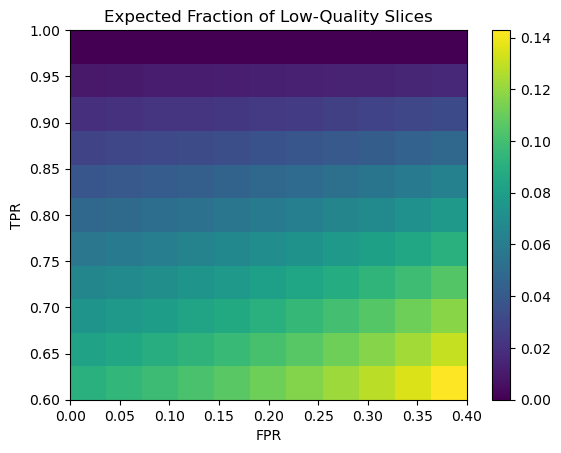

In [75]:
plt.imshow(p_FO, origin='lower', extent=fpr_range + tpr_range,
           aspect='auto') 

plt.colorbar()
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Expected Fraction of Low-Quality Slices')
plt.savefig('exp_frac')

# Plotting the metrics wrt model's thresholds

In [117]:
roc_json_path = Path('../outputs/models/conv_nxt/run3/test_info/model_auc_ROC.json')

In [118]:
with open(roc_json_path, 'r') as f:
    roc_dict = json.load(f)

fpr, tpr, ts = roc_dict['fpr'], roc_dict['tpr'], roc_dict['ts']
FPR = np.array(fpr)
TPR = np.array(tpr)

In [132]:
p_acc = q * (1 - TPR) + (1-q) * (1 - FPR)
p_FO = q * (1 - TPR) / p_acc 

expected_count = (s / p_acc) 
expected_frac = p_FO

var_count = (s * (1 - p_acc)) / (p_acc ** 2)
var_frac = p_FO * (1 - p_FO) / s

/tmp/ipykernel_2642842/583802686.py:2: RuntimeWarning: invalid value encountered in divide
  p_FO = q * (1 - TPR) / p_acc
/tmp/ipykernel_2642842/583802686.py:4: RuntimeWarning: divide by zero encountered in divide
  expected_count = (s / p_acc)
/tmp/ipykernel_2642842/583802686.py:7: RuntimeWarning: divide by zero encountered in divide
  var_count = (s * (1 - p_acc)) / (p_acc ** 2)


In [133]:
expected_count_old = s

expected_frac_old = q
var_frac_old = q * (1 - q) / s

In [134]:
std_count = np.sqrt(var_count)
std_frac = np.sqrt(var_frac)
std_frac_old = np.sqrt(var_frac_old)

/tmp/ipykernel_2642842/1664409427.py:7: RuntimeWarning: invalid value encountered in subtract
  expected_count - std_count,


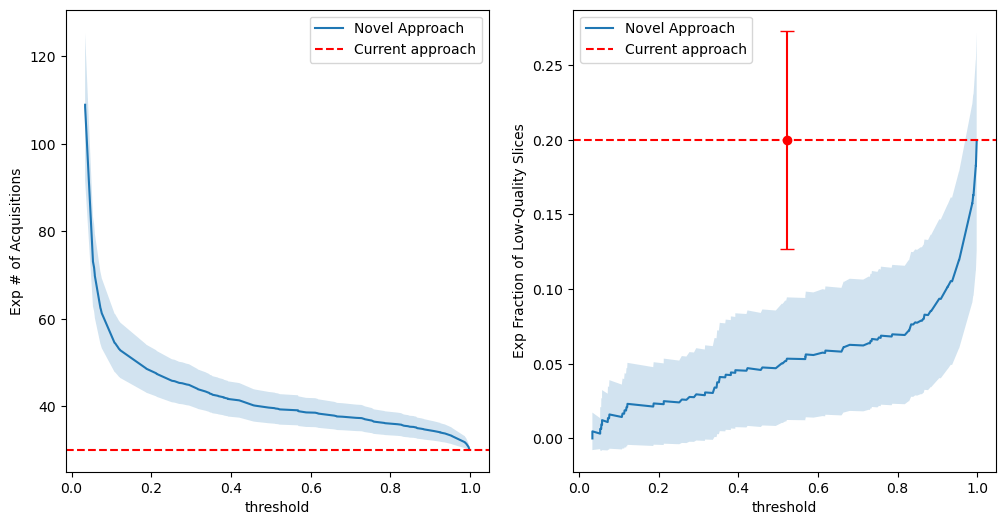

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# --- Expected count ---
ax[0].plot(ts, expected_count, label="Novel Approach")
ax[0].fill_between(
    ts,
    expected_count - std_count,
    expected_count + std_count,
    alpha=0.2,
)
ax[0].set_xlabel('threshold')
ax[0].set_ylabel('Exp # of Acquisitions')
ax[0].axhline(y=expected_count_old, linestyle='--', label='Current approach', color = 'red')
ax[0].legend()

# --- p_FO ---
ax[1].plot(ts, expected_frac, label="Novel Approach")
ax[1].fill_between(
    ts,
    expected_frac - std_frac,
    expected_frac + std_frac,
    alpha=0.2,
)

ax[1].axhline(y=expected_frac_old, linestyle='--', label='Current approach', color = 'red')
ax[1].errorbar(
    ts[len(ts) // 2],
    expected_frac_old,
    yerr=std_frac_old,
    fmt='o',
    color='red',
    capsize=5,
)

ax[1].set_xlabel('threshold')
ax[1].set_ylabel('Exp Fraction of Low-Quality Slices')
ax[1].legend()